In [11]:
# from datasets import load_dataset
# import matplotlib.pyplot as plt 

# ds = load_dataset("food101",cache_dir="/data/date_Taohy/.cache/huggingface/datasets")

# print(ds)
# print(ds['train'].features['label'].names)
# print(ds['train']['image'][:1])
# plt.imshow(ds['train'][0]['image'])


In [12]:
# import os
# from tqdm import tqdm
# from datasets import load_from_disk

# # 设置输出路径
# output_dir = '/data/data_taohy/awesomeCopression/food101_images'
# os.makedirs(output_dir, exist_ok=True)

# # 获取类别名称（Food-101有101个食物类别）
# class_names = ds['train'].features['label'].names

# # 处理训练集和验证集
# for split in ['train', 'validation']:
#     print(f"\n正在处理 {split} 集...")
#     split_dir = os.path.join(output_dir, split)
#     os.makedirs(split_dir, exist_ok=True)
    
#     # 遍历数据（tqdm显示进度条）
#     for i, sample in enumerate(tqdm(ds[split], desc=f"保存 {split}")):
#         image = sample['image']  # PIL.Image 对象
#         label_idx = sample['label']
#         class_name = class_names[label_idx]
        
#         # 创建类别文件夹（如 apple_pie, baby_back_ribs...）
#         class_dir = os.path.join(split_dir, class_name)
#         os.makedirs(class_dir, exist_ok=True)
        
#         # 保存图片（使用原始索引命名，避免重复）
#         img_path = os.path.join(class_dir, f"{i}.jpg")
#         image.save(img_path, quality=95)
        
#         # 可选：同时保存标签信息（方便后续查看）
#         if i == 0:  # 每个类别只写一次说明
#             with open(os.path.join(class_dir, 'label.txt'), 'w') as f:
#                 f.write(f"Class: {class_name}\nIndex: {label_idx}")

# print(f"\n✅ 完成！图片保存在: {output_dir}")


In [13]:
import torch
import torch.nn as nn

def init_alexnet_weights(model):
    # 按 AlexNet 风格初始化
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            # conv 权重 ~ N(0, 0.01)
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
        elif isinstance(m, nn.Linear):
            # fc 权重 ~ N(0, 0.01)，bias = 0
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

class Alexnet(nn.Module):
    def __init__(self, num_classes=101):
        super(Alexnet, self).__init__()
        # 128*128
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 3 * 3, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # 展平
        x = self.classifier(x)
        return x

In [14]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt


class DataSetLoader(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # 收集所有 (img_path, label_idx)
        self.samples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # 用 PIL 读图，更稳
        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)
        else:
            # 默认变换
            transform = T.Compose(
                [
                    T.Resize((256, 256)),
                    T.ToTensor(),
                ]
            )
            image = transform(image)

        return image, label

In [15]:
# AlexNet 风格的 RGB intensity 扰动（PCA lighting）
class AlexNetLighting:
    def __init__(self, alphastd=0.1):
        self.alphastd = alphastd
        self.eigval = torch.tensor([0.2175, 0.0188, 0.0045])
        self.eigvec = torch.tensor(
            [
                [-0.5675, 0.7192, 0.4009],
                [-0.5808, -0.0045, -0.8140],
                [-0.5836, -0.6948, 0.4203],
            ]
        )

    def __call__(self, img):
        if self.alphastd == 0:
            return img
        alpha = torch.normal(mean=0.0, std=self.alphastd, size=(3,))
        rgb = (self.eigvec * alpha * self.eigval).sum(dim=1)
        return torch.clamp(img + rgb.view(3, 1, 1), 0.0, 1.0)


# 5-crop（四角+中心）+ 水平翻转 => 每张图 10 个视图
ten_crop_to_tensor = T.Compose(
    [
        T.TenCrop(128),
        T.Lambda(lambda crops: torch.stack([T.ToTensor()(crop) for crop in crops])),
        T.Lambda(lambda crops: torch.stack([AlexNetLighting(alphastd=0.1)(crop) for crop in crops])),
        T.Lambda(
            lambda crops: torch.stack(
                [
                    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(crop)
                    for crop in crops
                ]
            )
        ),
    ]
)

In [16]:
from tqdm import tqdm


def train(model, epoch, train_loader, optimizer, criterion, device, scheduler):
    correct_ = []
    loss_ = []
    for ep in range(epoch):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f"训练中 [{ep+1}/{epoch}]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            if images.dim() == 5:
                # 输入为 [B, 10, C, H, W]，将 10 个视图的预测取平均
                bsz, ncrops, c, h, w = images.size()
                outputs = model(images.view(-1, c, h, w))
                outputs = outputs.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total
        correct_.append(accuracy)
        loss_.append(avg_loss)
        print(
            f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 准确率: {accuracy:.4f} total: {total} correct: {correct}"
        )

        try:
            scheduler.step(accuracy)
        except NameError:
            # 如果 notebook 中没有定义 scheduler，就跳过调度
            pass
    return correct_, loss_

In [17]:
def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="测试中"):
            images, labels = images.to(device), labels.to(device)
            if images.dim() == 5:
                bsz, ncrops, c, h, w = images.size()
                outputs = model(images.view(-1, c, h, w))
                outputs = outputs.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"测试准确率: {accuracy:.4f}")

In [18]:
def show_correct_and_loss(correct, loss, correct_add=None, loss_add=None):
  if correct_add is not None:
    correct = correct + correct_add
  if loss_add is not None:
    loss = loss + loss_add

  epochs = range(1, len(correct) + 1)

  best_idx_cor = max(range(len(correct)), key=lambda i: correct[i])
  best_idx_loss = min(range(len(loss)), key=lambda i: loss[i])

  fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

  # Accuracy
  axes[0].plot(epochs, correct, marker="o", linewidth=2, label="Accuracy", color="#1f77b4")
  axes[0].scatter(best_idx_cor + 1, correct[best_idx_cor], color="red", s=80, zorder=3, label="Best Accuracy")
  axes[0].annotate(
    f"{correct[best_idx_cor]:.4f}",
    xy=(best_idx_cor + 1, correct[best_idx_cor]),
    xytext=(5, 8),
    textcoords="offset points",
    color="red",
  )
  axes[0].set_title("Training Accuracy")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Accuracy")
  axes[0].set_xticks(list(epochs))
  axes[0].grid(True, linestyle="--", alpha=0.4)
  axes[0].legend()

  # Loss
  axes[1].plot(epochs, loss, marker="o", linewidth=2, label="Loss", color="#ff7f0e")
  axes[1].scatter(best_idx_loss + 1, loss[best_idx_loss], color="green", s=80, zorder=3, label="Best Loss")
  axes[1].annotate(
    f"{loss[best_idx_loss]:.4f}",
    xy=(best_idx_loss + 1, loss[best_idx_loss]),
    xytext=(5, 8),
    textcoords="offset points",
    color="green",
  )
  axes[1].set_title("Training Loss")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Loss")
  axes[1].set_xticks(list(epochs))
  axes[1].grid(True, linestyle="--", alpha=0.4)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

In [20]:
train_dir = "/data/data_taohy/awesomeCopression/food101_images/train"
test_dir = "/data/data_taohy/awesomeCopression/food101_images/validation"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Alexnet()
init_alexnet_weights(model)  # 初始化权重

print("模型初始化完成，准备训练...")
if torch.cuda.device_count() > 1:
    print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
    model = nn.DataParallel(model)
model = model.to(device)


optimizer = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4
)
scheduler_base = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",  # 监控准确率（越大越好）
    factor=0.1,  # 乘以 0.1（即除以 10）
    patience=5,  # 等待 5 个 epoch 不改善才调整
)

criterion = nn.CrossEntropyLoss()


train_transform = T.Compose(
    [
        T.Resize(150),
        ten_crop_to_tensor,
    ]
)

test_transform = T.Compose(
    [
        T.Resize(150),
        T.TenCrop(128),
        T.Lambda(lambda crops: torch.stack([T.ToTensor()(crop) for crop in crops])),
        T.Lambda(
            lambda crops: torch.stack(
                [
                    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(
                        crop
                    )
                    for crop in crops
                ]
            )
        ),
    ]
)

train_loader = DataLoader(
    DataSetLoader(train_dir, transform=train_transform),
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
)
test_loader = DataLoader(
    DataSetLoader(test_dir, transform=test_transform),
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
)


if __name__ == "__main__":
    correct, loss = train(
        model,
        epoch=60,
        train_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        scheduler=scheduler_base,
    )
    test(model, test_loader=test_loader, device=device)

模型初始化完成，准备训练...
使用多卡训练, GPU 数量: 4


训练中 [1/60]: 100%|██████████| 1184/1184 [02:28<00:00,  7.97it/s]


Epoch [1/60] 平均损失: 4.6158 准确率: 0.0091 total: 75750 correct: 690


训练中 [2/60]: 100%|██████████| 1184/1184 [02:27<00:00,  8.02it/s]


Epoch [2/60] 平均损失: 4.6062 准确率: 0.0106 total: 75750 correct: 804


...

Epoch [59/60] 平均损失: 0.5295 准确率: 0.8403 total: 75750 correct: 63649


训练中 [60/60]: 100%|██████████| 1184/1184 [02:24<00:00,  8.18it/s]


Epoch [60/60] 平均损失: 0.5233 准确率: 0.8404 total: 75750 correct: 63657


测试中: 100%|██████████| 395/395 [00:37<00:00, 10.42it/s]

测试准确率: 0.4604


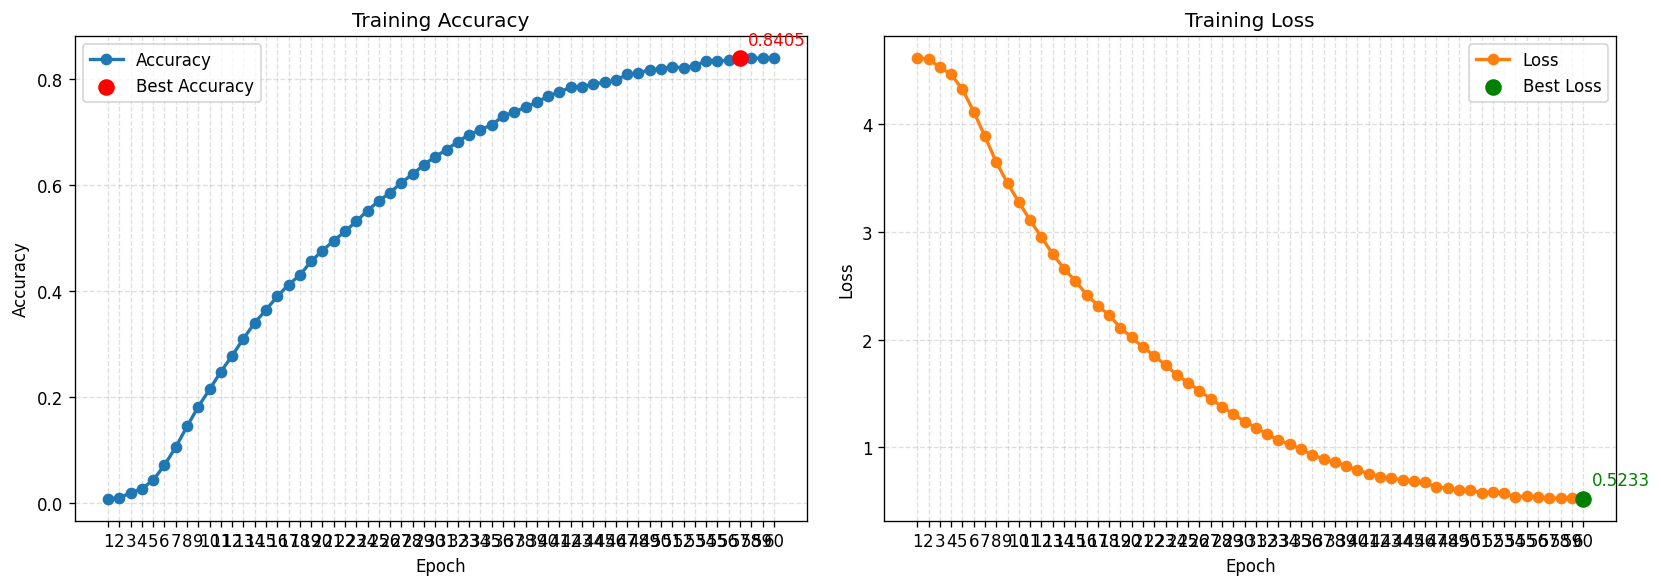

In [21]:
show_correct_and_loss(correct, loss)

In [22]:
correct_add, loss_add = train(
    model,
    epoch=40,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
)
test(model, test_loader=test_loader, device=device)

训练中 [1/40]: 100%|██████████| 1184/1184 [02:26<00:00,  8.06it/s]


Epoch [1/40] 平均损失: 0.5097 准确率: 0.8438 total: 75750 correct: 63918


训练中 [2/40]: 100%|██████████| 1184/1184 [02:27<00:00,  8.03it/s]


Epoch [2/40] 平均损失: 0.5093 准确率: 0.8444 total: 75750 correct: 63963


训练中 [3/40]: 100%|██████████| 1184/1184 [02:26<00:00,  8.07it/s]


...

Epoch [39/40] 平均损失: 0.0104 准确率: 0.9987 total: 75750 correct: 75653


训练中 [40/40]: 100%|██████████| 1184/1184 [02:26<00:00,  8.08it/s]


Epoch [40/40] 平均损失: 0.0104 准确率: 0.9986 total: 75750 correct: 75647


测试中: 100%|██████████| 395/395 [00:39<00:00,  9.90it/s]

测试准确率: 0.5160


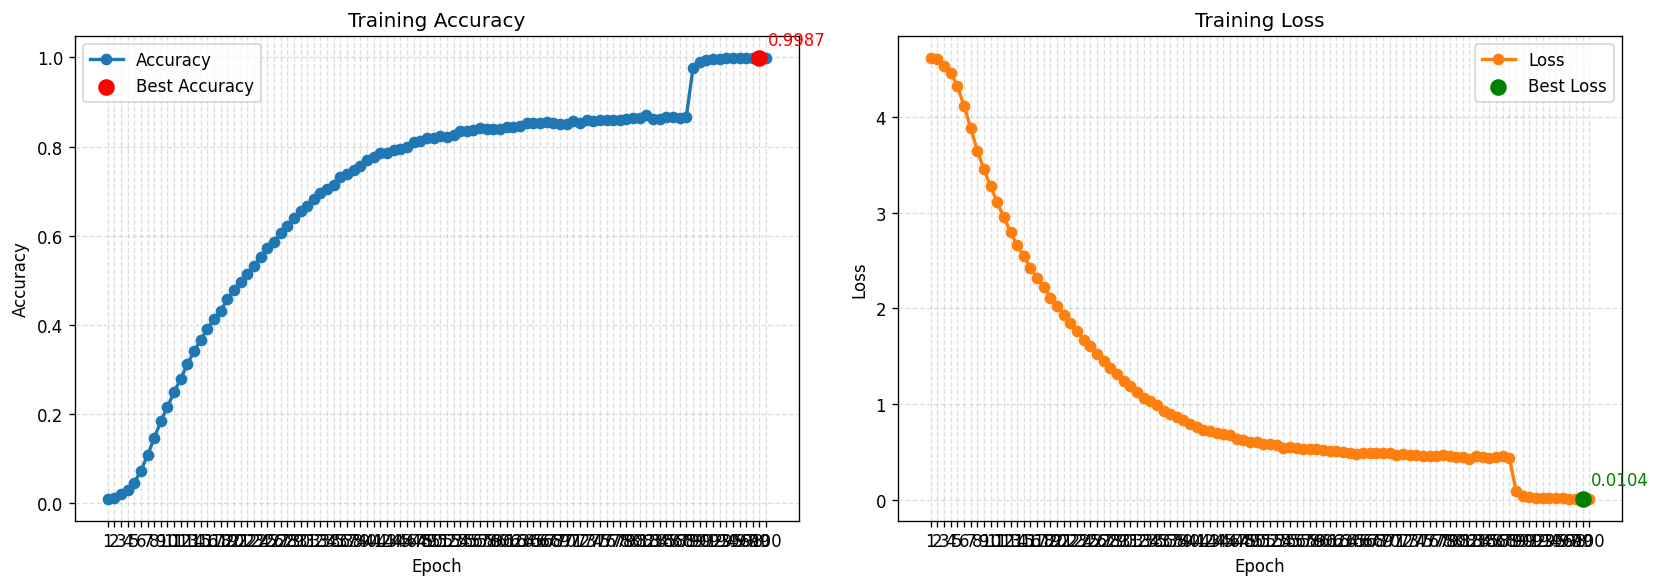

In [23]:
show_correct_and_loss(correct, loss,correct_add=correct_add, loss_add=loss_add)

In [ ]:
import os
from datetime import datetime

# 保存/加载检查点的实用函数（在新的 notebook cell 中执行）
def save_checkpoint(path, model, optimizer, scheduler=None, epoch=None, best_acc=None):
  os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
  # 如果使用了 DataParallel，保存 module 的 state_dict
  state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
  checkpoint = {
    "epoch": epoch,
    "model_state_dict": state_dict,
    "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "best_acc": best_acc,
    "saved_at": datetime.utcnow().isoformat(),
  }
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None, map_location=device):
  checkpoint = torch.load(path, map_location=map_location)
  # 如果当前 model 是 DataParallel，需要把 state_dict 加载到 module
  target = model.module if hasattr(model, "module") else model
  target.load_state_dict(checkpoint["model_state_dict"])
  if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
  print(f"Loaded checkpoint from {path}, epoch={checkpoint.get('epoch')}, best_acc={checkpoint.get('best_acc')}")
  return checkpoint


save_checkpoint("/data/data_taohy/awesomeCopression/model/alexnet_food5_dataimprovement.pth", model, optimizer)
# ckpt = load_checkpoint("/data/data_taohy/awesomeCopression/model/alexnet_food101.pth", model, optimizer, scheduler)

Saved checkpoint to /data/data_taohy/awesomeCopression/model/alexnet_food5_dataimprovement.pth
